# Notebook 11 — Diagnostico del modelo (residuales, sesgo y contenido de NASA)

Este notebook produce los diagnosticos complementarios de la Actividad 3 a partir de los **modelos ya entrenados** en el Notebook 06 (`MODO = 'completo'`). **No reentrena nada**: carga los checkpoints guardados en `modelos/` y regenera las predicciones por inferencia, de modo que puede ejecutarse en una sesion nueva de Colab sin repetir el entrenamiento.

**Como ejecutarlo:** correr todas las celdas de arriba hacia abajo. Las celdas de preparacion (montaje, carga de artefactos, definiciones) son las mismas del Notebook 06 y solo definen funciones y cargan datos; el entrenamiento no se ejecuta.

**Contenido (los cuatro puntos del diagnostico):**
1. Diagnostico de residuales del modelo: error medio (sesgo), sesgo por nivel de irradiancia y por hora del dia, autocorrelacion de residuales (ACF y Ljung-Box) y residual frente a observado.
2. Figura de prediccion frente a observacion con **ventanas representativas** (corrige la version anterior, que elegia la ventana mas volatil).
3. Diagnostico del contenido de alta frecuencia de las variables de NASA POWER frente a la RS de la estacion.
4. Tabla de metricas ampliada con el **error medio (ME)** como base del analisis de sesgo.

**Encuadre metodologico:** estos analisis son un *diagnostico del modelo*, no una validacion de supuestos estadisticos. El Informer no descansa sobre supuestos de normalidad, homocedasticidad o ausencia de multicolinealidad; los residuales se examinan para caracterizar donde y como se equivoca el modelo, no para validar su legitimidad.

---
## Cambios de la revision (septiembre de 2026)

Este cuaderno es el 07 original con cuatro correcciones. Todas responden a
peticiones de la direccion y todas buscan que el diagnostico describa
exactamente el mismo modelo que reporta el cuaderno 06.

1. **Particion con embargo.** `build_loaders` y `predecir_contiguo` leen ahora
   los indices `idx_*_ini` / `idx_*_fin` de `config_fe.pkl`. Antes el conjunto
   de prueba empezaba en `idx_val_end`, que con el embargo es el comienzo de la
   banda descartada: el diagnostico se hacia sobre 576 pasos que ya no
   pertenecen al conjunto de prueba.

2. **Restricciones fisicas, a las dos series.** Las predicciones del modelo y
   las de la persistencia pasan por `ajustar_prediccion()`, la misma funcion
   del cuaderno 06. Sin esto, la tabla de sesgo de este cuaderno y la tabla de
   metricas del 06 describirian predicciones distintas.

3. **Residuales diagnosticados en la franja diurna.** Con la restriccion
   aplicada, el residual nocturno es identicamente cero. Una serie con doce
   horas de ceros exactos cada dia tiene una periodicidad artificial que
   domina la autocorrelacion y dispara la prueba de Ljung-Box. La ACF se
   calcula ahora sobre pares en que los dos puntos son diurnos, y la prueba se
   construye con esas autocorrelaciones. Se reporta tambien la version
   completa, para que la diferencia quede a la vista.

4. **Nombre del archivo de salida.** La tabla de este cuaderno se guarda como
   `metricas_variantes_con_ME.csv`. Antes se llamaba `metricas_variantes.csv`,
   el mismo nombre que escribe el cuaderno 06, y el ultimo en ejecutarse
   sobreescribia al otro.

**Requisito:** ejecutar antes los cuadernos 04, 05 y 06 revisados.

---

In [ ]:
# 1. Configuracion del entorno
!pip install torch numpy pandas matplotlib scikit-learn statsmodels --quiet

import os, sys, gc, time, pickle, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_TYPE = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP     = torch.cuda.is_available()

# El estilo de las figuras (paleta y tamanos de letra) se define en la celda
# siguiente, la celda de estilo, para que sea identico en los 11 cuadernos.

# Debe coincidir con el MODO usado al entrenar en el Notebook 06.
# Los checkpoints se llaman informer_..._completo.pt, por lo que aqui va 'completo'.
MODO = 'completo'

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
print('MODO    :', MODO)

PyTorch : 2.11.0+cu128
Device  : cuda
MODO    : completo


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
archivo_de_datos('config_fe.pkl', pista='Lo genera el cuaderno 04.')


Mounted at /content/drive
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados


'/content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos/arrays/config_fe.pkl'

### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


In [ ]:
# 3. Arquitectura de referencia: Informer oficial (zhouhaoyi/Informer2020)
REPO_INFORMER = '/content/Informer2020'
if not os.path.exists(REPO_INFORMER):
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/zhouhaoyi/Informer2020.git',
                    REPO_INFORMER], check=True)
if REPO_INFORMER not in sys.path:
    sys.path.append(REPO_INFORMER)

from models.model import Informer
print('Arquitectura Informer importada correctamente.')

Arquitectura Informer importada correctamente.


In [ ]:
# 4. Carga de artefactos del Notebook 04 y de la mejor configuracion (Notebook 05)
data_norm   = np.load(os.path.join(RUTA_ARRAYS, 'data_norm.npy'))
marcas_temp = np.load(os.path.join(RUTA_ARRAYS, 'marcas_temp.npy'))
with open(os.path.join(RUTA_ARRAYS, 'config_fe.pkl'), 'rb') as f:
    config = pickle.load(f)
with open(os.path.join(RUTA_ARRAYS, 'scaler_rs.pkl'), 'rb') as f:
    scaler_rs = pickle.load(f)

VARS_ENTRADA  = list(config['vars_entrada'])
VAR_OBJETIVO  = config['var_objetivo']
SEQ_LEN       = config['seq_len']
LABEL_LEN     = config['label_len']
PRED_LENS     = config['pred_lens']
IDX_TRAIN_END = config['idx_train_end']
IDX_VAL_END   = config['idx_val_end']
N_TOTAL       = config['n_total']
RS_MIN   = float(scaler_rs.data_min_[0])
RS_RANGE = float(scaler_rs.data_range_[0])

# --- Indices con embargo — PARCHE DE LA REVISION -------------------------
IDX_TRAIN_INI = config.get('idx_train_ini', 0)
IDX_TRAIN_FIN = config.get('idx_train_fin', IDX_TRAIN_END)
IDX_VAL_INI   = config.get('idx_val_ini',   IDX_TRAIN_END)
IDX_VAL_FIN   = config.get('idx_val_fin',   IDX_VAL_END)
IDX_TEST_INI  = config.get('idx_test_ini',  IDX_VAL_END)
IDX_TEST_FIN  = config.get('idx_test_fin',  N_TOTAL)
EMBARGO       = config.get('embargo', 0)

# --- Marcas de tiempo reales de cada fila --------------------------------
# Necesarias para la franja diurna. Se reconstruyen si el archivo no existe.
ruta_ts = os.path.join(RUTA_ARRAYS, 'timestamps.npy')
if os.path.exists(ruta_ts):
    TIMESTAMPS = pd.DatetimeIndex(np.load(ruta_ts))
else:
    TIMESTAMPS = pd.date_range(start=config['fecha_inicio'],
                               periods=N_TOTAL,
                               freq=f"{config.get('freq_min', 5)}min")
    print('AVISO: timestamps.npy no encontrado; se reconstruyen por rango.')

HORA_INI_DIURNO = 6
HORA_FIN_DIURNO = 18

ruta_hp = os.path.join(RUTA_RES, 'hp_best.pkl')
if not os.path.exists(ruta_hp):
    raise FileNotFoundError('No se encontro hp_best.pkl. Ejecute primero el Notebook 05 '
                            '(idealmente en MODO completo).')
with open(ruta_hp, 'rb') as f:
    HP_BEST = pickle.load(f)

print('data_norm :', data_norm.shape, '| RS_range:', round(RS_RANGE, 1), 'W/m2')
print('Horizontes:', PRED_LENS)
print()
print(f'Embargo   : {EMBARGO} pasos por frontera')
print(f'Bloques   : train [{IDX_TRAIN_INI}, {IDX_TRAIN_FIN})  '
      f'val [{IDX_VAL_INI}, {IDX_VAL_FIN})  test [{IDX_TEST_INI}, {IDX_TEST_FIN})')
if EMBARGO == 0:
    print()
    print('AVISO: los artefactos no traen embargo. Reejecuta el cuaderno 04 revisado')
    print('antes de continuar, o el diagnostico no correspondera al modelo del 06.')
print()
print('Hiperparametros seleccionados (hp_best.pkl):')
for k, v in HP_BEST.items():
    print(f'  {k:<10}: {v}')

data_norm : (1330560, 18) | RS_range: 1524.0 W/m2
Horizontes: {'1h': 12, '3h': 36, '6h': 72}

Embargo   : 576 pasos por frontera
Bloques   : train [0, 931391)  val [931967, 1130976)  test [1131552, 1330560)

Hiperparametros seleccionados (hp_best.pkl):
  d_model   : 512
  n_heads   : 8
  e_layers  : 2
  d_layers  : 2
  d_ff      : 256
  dropout   : 0.1
  factor    : 3
  lr        : 0.001


## Preparacion (identica al Notebook 06)

Las celdas siguientes son las mismas del Notebook 06: montan Drive, clonan el Informer, cargan los artefactos y `hp_best.pkl`, y definen las variantes, el `InformerDataset`, los constructores y las funciones de evaluacion. **Ninguna entrena.** Solo dejan en memoria lo necesario para evaluar los modelos ya guardados.

In [ ]:
# 6. Variantes y clase InformerDataset
GRUPOS_VARIABLES = {
    'V1_autorregresivo': ['RS', 'sin_hora', 'cos_hora',
                          'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes'],
    'V2_meteo_nasa': ['RS', 'sin_hora', 'cos_hora',
                      'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes',
                      'T2M', 'RH2M', 'PRECTOTCORR',
                      'WS10M', 'WD10M_u', 'WD10M_v', 'PS', 'SZA'],
    'V3_completo': list(VARS_ENTRADA),
}

def columnas_variante(nombre_variante):
    return [VARS_ENTRADA.index(v) for v in GRUPOS_VARIABLES[nombre_variante]]

class InformerDataset(Dataset):
    def __init__(self, data, marcas, idx_inicio, idx_fin,
                 seq_len, label_len, pred_len, idx_objetivo):
        self.data, self.marcas = data, marcas
        self.seq_len, self.label_len, self.pred_len = seq_len, label_len, pred_len
        self.idx_objetivo = idx_objetivo
        self._inicio = max(idx_inicio, seq_len)
        self._fin    = min(idx_fin, len(data) - pred_len)
        self._len    = max(0, self._fin - self._inicio)

    def __len__(self):
        return self._len

    def __getitem__(self, i):
        t = self._inicio + i
        enc_input = self.data[t - self.seq_len:t, :]
        enc_mark  = self.marcas[t - self.seq_len:t, :]
        dec_input = self.data[t - self.label_len:t + self.pred_len, :].copy()
        dec_mark  = self.marcas[t - self.label_len:t + self.pred_len, :]
        dec_input[self.label_len:, self.idx_objetivo] = 0.0
        target = self.data[t:t + self.pred_len, self.idx_objetivo]
        return (torch.from_numpy(enc_input), torch.from_numpy(enc_mark),
                torch.from_numpy(dec_input), torch.from_numpy(dec_mark),
                torch.from_numpy(target))

print('Variantes y InformerDataset definidos.')

Variantes y InformerDataset definidos.


In [ ]:
# 7. Constructores de DataLoaders y del modelo
def build_loaders(nombre_variante, nombre_horizonte,
                  stride_train, stride_eval, batch_size, num_workers=2):
    cols     = columnas_variante(nombre_variante)
    data_sub = np.ascontiguousarray(data_norm[:, cols])
    pred_len = PRED_LENS[nombre_horizonte]
    enc_in   = data_sub.shape[1]
    # PARCHE DE LA REVISION: limites con embargo, identicos a los del cuaderno 06.
    splits = [('train', IDX_TRAIN_INI, IDX_TRAIN_FIN, stride_train),
              ('val',   IDX_VAL_INI,   IDX_VAL_FIN,   stride_eval),
              ('test',  IDX_TEST_INI,  IDX_TEST_FIN,  stride_eval)]
    loaders, tam = {}, {}
    for split, i_ini, i_fin, stride in splits:
        ds_full = InformerDataset(data_sub, marcas_temp, i_ini, i_fin,
                                  SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0)
        ds = Subset(ds_full, list(range(0, len(ds_full), stride)))
        loaders[split] = DataLoader(ds, batch_size=batch_size,
                                    shuffle=(split == 'train'),
                                    num_workers=num_workers, pin_memory=USE_AMP,
                                    drop_last=(split == 'train'))
        tam[split] = len(ds)
    return loaders, enc_in, pred_len, tam

def build_informer(enc_in, pred_len, hp):
    return Informer(
        enc_in=enc_in, dec_in=enc_in, c_out=1,
        seq_len=SEQ_LEN, label_len=LABEL_LEN, out_len=pred_len,
        factor=hp['factor'], d_model=hp['d_model'], n_heads=hp['n_heads'],
        e_layers=hp['e_layers'], d_layers=hp['d_layers'], d_ff=hp['d_ff'],
        dropout=hp['dropout'], attn='prob', embed='timeF', freq='h',
        activation='gelu', output_attention=False, distil=True, mix=True,
        device=DEVICE
    ).to(DEVICE)

# --- Alineamiento temporal y restricciones fisicas — PARCHE DE LA REVISION ---
def indices_globales(i_ini, i_fin, pred_len, stride):
    """Fila del arreglo original a la que corresponde cada punto predicho.

    Reproduce la aritmetica de InformerDataset mas el submuestreo por Subset:
    el origen de la ventana j esta en i_ini + j*stride y su objetivo ocupa los
    pred_len pasos siguientes. Es identica a la del cuaderno 06.
    """
    inicio   = max(i_ini, SEQ_LEN)
    fin      = min(i_fin, N_TOTAL - pred_len)
    n        = max(0, fin - inicio)
    origenes = np.arange(0, n, stride) + inicio
    return origenes[:, None] + np.arange(pred_len)[None, :]

def ajustar_prediccion(idx_glob, yhat):
    """No negatividad e irradiancia nula fuera de la franja diurna.

    Identica a la del cuaderno 06. Se aplica por igual al modelo y a la linea
    base de persistencia.
    """
    idx_glob = np.asarray(idx_glob)
    horas = TIMESTAMPS[idx_glob.ravel()].hour.values.reshape(idx_glob.shape)
    out = np.clip(np.asarray(yhat, dtype=float).copy(), 0.0, None)
    out[~((horas >= HORA_INI_DIURNO) & (horas <= HORA_FIN_DIURNO))] = 0.0
    return out

print('Constructores y funciones de alineamiento definidos.')

Constructores y funciones de alineamiento definidos.


In [ ]:
# 8. Motor de entrenamiento (identico al del Notebook 05)
def _mover(batch):
    enc, enc_m, dec, dec_m, tgt = batch
    return (enc.to(DEVICE), enc_m.to(DEVICE), dec.to(DEVICE),
            dec_m.to(DEVICE), tgt.to(DEVICE))

@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = model(enc, enc_m, dec, dec_m).squeeze(-1)
            loss = criterion(out, tgt)
        total += loss.item() * tgt.size(0); n += tgt.size(0)
    return total / max(n, 1)

def train_model(model, loaders, max_epochs, lr, weight_decay=1e-4,
                patience=4, clip=1.0, ruta_ckpt=None, verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    scaler = GradScaler(DEVICE_TYPE, enabled=USE_AMP)
    historia = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val, sin_mejora = float('inf'), 0
    for epoch in range(1, max_epochs + 1):
        model.train(); t0, suma, n = time.time(), 0.0, 0
        for batch in loaders['train']:
            enc, enc_m, dec, dec_m, tgt = _mover(batch)
            optimizer.zero_grad(set_to_none=True)
            with autocast(DEVICE_TYPE, enabled=USE_AMP):
                out = model(enc, enc_m, dec, dec_m).squeeze(-1)
                loss = criterion(out, tgt)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer); scaler.update()
            suma += loss.item() * tgt.size(0); n += tgt.size(0)
        train_loss = suma / max(n, 1)
        val_loss = evaluate_loss(model, loaders['val'], criterion)
        scheduler.step(val_loss)
        historia['train_loss'].append(train_loss)
        historia['val_loss'].append(val_loss)
        historia['lr'].append(optimizer.param_groups[0]['lr'])
        if verbose:
            print(f'  Epoca {epoch:>2}/{max_epochs} | train {train_loss:.5e} | val {val_loss:.5e} | {time.time()-t0:.1f}s')
        if val_loss < best_val - 1e-7:
            best_val, sin_mejora = val_loss, 0
            if ruta_ckpt is not None:
                torch.save(model.state_dict(), ruta_ckpt)
        else:
            sin_mejora += 1
            if sin_mejora >= patience:
                if verbose:
                    print(f'  Parada temprana en epoca {epoch}.')
                break
    return best_val, historia

print('Motor de entrenamiento definido.')

Motor de entrenamiento definido.


In [ ]:
# 10. Desnormalizacion, metricas y recoleccion de predicciones
def desnormalizar_rs(x_norm):
    return x_norm * RS_RANGE + RS_MIN   # [0,1] -> W/m2

def metricas(y_true, y_pred, umbral_diurno=10.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.clip(np.asarray(y_pred).ravel(), 0.0, None)  # irradiancia no negativa
    err = y_pred - y_true
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1 - np.sum(err ** 2) / ss_tot) if ss_tot > 0 else float('nan')
    m = y_true > umbral_diurno   # mascara diurna
    if m.sum() > 0:
        ed = y_pred[m] - y_true[m]
        mae_d  = float(np.mean(np.abs(ed)))
        rmse_d = float(np.sqrt(np.mean(ed ** 2)))
        sst_d  = float(np.sum((y_true[m] - y_true[m].mean()) ** 2))
        r2_d   = float(1 - np.sum(ed ** 2) / sst_d) if sst_d > 0 else float('nan')
        smape  = float(100 * np.mean(2 * np.abs(ed) / (np.abs(y_true[m]) + np.abs(y_pred[m]) + 1e-8)))
    else:
        mae_d = rmse_d = r2_d = smape = float('nan')
    return dict(MAE=mae, RMSE=rmse, R2=r2,
                MAE_diurno=mae_d, RMSE_diurno=rmse_d, R2_diurno=r2_d, sMAPE_diurno=smape)

@torch.no_grad()
def predecir(model, loader):
    model.eval()
    preds, trues, pers = [], [], []
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = model(enc, enc_m, dec, dec_m).squeeze(-1)
        preds.append(out.float().cpu().numpy())
        trues.append(tgt.float().cpu().numpy())
        ultimo = enc[:, -1, 0].float().cpu().numpy()[:, None]   # persistencia: ultimo RS observado
        pers.append(np.repeat(ultimo, tgt.shape[1], axis=1))
    return np.concatenate(preds), np.concatenate(trues), np.concatenate(pers)

print('Funciones de evaluacion definidas.')

Funciones de evaluacion definidas.


## Bloque de diagnostico (puntos 1 a 4)

A partir de aqui comienza el contenido nuevo. Cada celda carga los checkpoints, ejecuta inferencia sobre el conjunto de prueba y produce una tabla o figura para la seccion de Resultados. El modelo a diagnosticar en el analisis de residuales es configurable (`VAR_DIAG`, `H_DIAG`).

In [ ]:
# 12. Configuracion del diagnostico y funciones auxiliares
from statsmodels.stats.diagnostic import acorr_ljungbox

# Modelo a diagnosticar en el analisis de residuales (puede cambiarse).
VAR_DIAG = 'V2_meteo_nasa'       # variante para los residuales
H_DIAG   = '1h'                  # horizonte para los residuales
N_SEG    = 20000                 # longitud del tramo contiguo de prueba (pasos de 5 min)

# PARCHE DE LA REVISION: marca de origen de cada fila (True = medido por el
# sensor, False = rellenado por la imputacion). Permite separar el error del
# modelo sobre datos reales del error contra valores climatologicos.
_ruta_obs = os.path.join(RUTA_ARRAYS, 'observado.npy')
if os.path.exists(_ruta_obs):
    OBSERVADO = np.load(_ruta_obs)
    print(f'Marca de origen cargada: {OBSERVADO.mean()*100:.2f} % de los puntos son medidos')
else:
    OBSERVADO = None
    print('AVISO: falta observado.npy. Ejecuta de nuevo los cuadernos 02 y 04 si')
    print('       quieres separar el error sobre medidos del error sobre imputados.')


@torch.no_grad()
def predecir_contiguo(variante, horizonte, n_seg):
    """Predicciones ordenadas sobre un tramo contiguo del conjunto de prueba.

    Con stride igual a uno, para construir una serie de residuales sin huecos.
    PARCHE DE LA REVISION: el tramo arranca en IDX_TEST_INI, el comienzo real
    del conjunto de prueba una vez descontado el embargo. Antes arrancaba en
    IDX_VAL_END, que ahora es el primer paso de la banda descartada.
    """
    cols = columnas_variante(variante)
    data_sub = np.ascontiguousarray(data_norm[:, cols])
    pred_len = PRED_LENS[horizonte]
    i_fin = min(IDX_TEST_INI + n_seg, IDX_TEST_FIN)
    ds = InformerDataset(data_sub, marcas_temp, IDX_TEST_INI, i_fin,
                         SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0)
    loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=USE_AMP)
    ckpt = os.path.join(RUTA_MODELOS, f'informer_{variante}__{horizonte}_{MODO}.pt')
    modelo = build_informer(len(cols), pred_len, HP_BEST)
    modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE)); modelo.eval()
    preds, trues = [], []
    for batch in loader:
        enc, enc_m, dec, dec_m, tgt = _mover(batch)
        with autocast(DEVICE_TYPE, enabled=USE_AMP):
            out = modelo(enc, enc_m, dec, dec_m).squeeze(-1)
        preds.append(out.float().cpu().numpy()); trues.append(tgt.float().cpu().numpy())
    del modelo; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    p, t = np.concatenate(preds), np.concatenate(trues)
    # Fila global del PRIMER paso de cada ventana: el origen avanza de uno en uno
    origen0 = max(IDX_TEST_INI, SEQ_LEN)
    t_idx = np.arange(origen0, origen0 + len(p))
    return p, t, t_idx

def acf_enmascarada(x, mascara, nlags):
    """Autocorrelacion usando solo los pares en que ambos puntos son validos.

    Es el estimador habitual para series con huecos. Aqui el hueco es la noche:
    con la restriccion fisica aplicada, el residual nocturno es cero exacto, y
    doce horas de ceros por dia introducen una periodicidad que no proviene del
    modelo sino de la restriccion.
    """
    x = np.asarray(x, dtype=float)
    m = np.asarray(mascara, dtype=bool)
    xc = np.where(m, x - x[m].mean(), np.nan)
    var = np.nanmean(xc[m] ** 2)
    r, npares = [1.0], [int(m.sum())]
    for k in range(1, nlags + 1):
        a, b = xc[:-k], xc[k:]
        par = ~np.isnan(a) & ~np.isnan(b)
        nk = int(par.sum())
        r.append(float(np.mean(a[par] * b[par]) / var) if nk > 30 else np.nan)
        npares.append(nk)
    return np.array(r), np.array(npares)

def ljung_box_enmascarada(r, npares, lags):
    """Prueba de Ljung-Box adaptada a una serie con enmascaramiento.

    En la version estandar el estadistico usa el mismo tamanio de muestra para
    todos los retardos. Aqui el numero de pares disponibles cae con el retardo,
    porque un par solo cuenta si sus dos puntos son diurnos: a retardo 1 hay
    casi todos, a retardo 72 poco mas de la mitad. Usar el n completo en todos
    los retardos infla el estadistico y hace rechazar de mas. Se usa el
    conteo real de pares de cada retardo, con lo que cada termino n_k r_k^2 es
    aproximadamente ji-cuadrado con un grado de libertad bajo la hipotesis
    nula. Comprobado sobre ruido blanco simulado: no rechaza.
    """
    from scipy.stats import chi2
    filas = []
    for L in lags:
        rk = r[1:L + 1]
        nk = npares[1:L + 1].astype(float)
        val = float(np.nansum(nk * rk ** 2))
        filas.append({'retardo': L, 'Q': val, 'p': float(1 - chi2.cdf(val, L))})
    return pd.DataFrame(filas)

print('Configuracion y funciones auxiliares listas.')
print(f'Tramo contiguo desde el indice {IDX_TEST_INI} '
      f'({TIMESTAMPS[IDX_TEST_INI]}), primer paso real del conjunto de prueba.')

Marca de origen cargada: 83.06 % de los puntos son medidos
Configuracion y funciones auxiliares listas.
Tramo contiguo desde el indice 1131552 (2024-05-04 00:00:00), primer paso real del conjunto de prueba.


In [ ]:
# 13. PUNTO 4: tabla de metricas ampliada con el error medio (ME / sesgo)
#
# PARCHE DE LA REVISION: las predicciones del modelo y las de la persistencia
# pasan por ajustar_prediccion() antes de medir, igual que en el cuaderno 06.
# El ambito diurno se define por la hora del reloj, no por un umbral sobre la
# irradiancia observada: definirlo con el propio observado excluye los
# instantes diurnos realmente oscuros, que son los mas dificiles.
STRIDE_DIAG = 18

def metricas_con_me(y_true, y_pred, idx_glob):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    idx_glob = np.asarray(idx_glob)
    horas = TIMESTAMPS[idx_glob.ravel()].hour.values.reshape(yt.shape)
    diurno = ((horas >= HORA_INI_DIURNO) & (horas <= HORA_FIN_DIURNO)) & (yt > 0)

    def _bloque(a, b, suf):
        e = b - a
        sst = float(np.sum((a - a.mean()) ** 2)) if a.size else 0.0
        return {f'MAE{suf}' : float(np.mean(np.abs(e))) if e.size else np.nan,
                f'RMSE{suf}': float(np.sqrt(np.mean(e ** 2))) if e.size else np.nan,
                f'R2{suf}'  : float(1 - np.sum(e ** 2) / sst) if sst > 0 else np.nan,
                f'ME{suf}'  : float(np.mean(e)) if e.size else np.nan}

    d = {'n_global': int(yt.size), 'n_diurno': int(diurno.sum())}
    d.update(_bloque(yt.ravel(), yp.ravel(), ''))
    d.update(_bloque(yt[diurno], yp[diurno], '_diurno'))
    ytd, ypd = yt[diurno], yp[diurno]
    d['sMAPE_diurno'] = float(100 * np.mean(
        2 * np.abs(ypd - ytd) / (np.abs(ytd) + np.abs(ypd) + 1e-8))) if ytd.size else np.nan
    return d

filas = []
for variante in GRUPOS_VARIABLES:
    for horizonte in PRED_LENS:
        ckpt = os.path.join(RUTA_MODELOS, f'informer_{variante}__{horizonte}_{MODO}.pt')
        if not os.path.exists(ckpt):
            print(f'[{variante}__{horizonte}] sin checkpoint, se omite.'); continue
        loaders, enc_in, pred_len, _ = build_loaders(
            variante, horizonte, STRIDE_DIAG, STRIDE_DIAG, 64)
        modelo = build_informer(enc_in, pred_len, HP_BEST)
        modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        p, t, per = predecir(modelo, loaders['test'])
        p_w, t_w, per_w = desnormalizar_rs(p), desnormalizar_rs(t), desnormalizar_rs(per)

        ig = indices_globales(IDX_TEST_INI, IDX_TEST_FIN, pred_len, STRIDE_DIAG)
        assert ig.shape == t_w.shape, (
            f'Desajuste de forma: indices {ig.shape} frente a predicciones {t_w.shape}')
        p_aj, per_aj = ajustar_prediccion(ig, p_w), ajustar_prediccion(ig, per_w)

        m_mod = metricas_con_me(t_w, p_aj,   ig)
        m_per = metricas_con_me(t_w, per_aj, ig)
        skill = float(1 - m_mod['RMSE'] / m_per['RMSE']) if m_per['RMSE'] > 0 else np.nan
        filas.append(dict(variante=variante, horizonte=horizonte, **m_mod,
                          RMSE_persistencia=m_per['RMSE'], skill_RMSE=skill))
        print(f"[{variante}__{horizonte}] ME={m_mod['ME']:+7.2f} | "
              f"ME_diurno={m_mod['ME_diurno']:+7.2f} | RMSE_diurno={m_mod['RMSE_diurno']:.1f}")
        del modelo, loaders; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

orden = ['variante','horizonte','MAE','RMSE','R2','ME',
         'MAE_diurno','RMSE_diurno','R2_diurno','ME_diurno','sMAPE_diurno',
         'RMSE_persistencia','skill_RMSE','n_global','n_diurno']
df_me = pd.DataFrame(filas)
df_me = df_me[[c for c in orden if c in df_me.columns]]
# Nombre distinto del que usa el cuaderno 06, para que no se pisen.
df_me.to_csv(os.path.join(RUTA_RES, 'metricas_variantes_con_ME.csv'), index=False)
print()
print(df_me.round(3).to_string(index=False))
print()
print('Tabla guardada: resultados/metricas_variantes_con_ME.csv')
print('El signo de ME dice la direccion del sesgo: positivo sobreestima, negativo subestima.')

[V1_autorregresivo__1h] ME=  -0.28 | ME_diurno= -45.18 | RMSE_diurno=217.7
[V1_autorregresivo__3h] ME=  +2.67 | ME_diurno= -19.14 | RMSE_diurno=197.4
[V1_autorregresivo__6h] ME=  +7.98 | ME_diurno= -31.57 | RMSE_diurno=218.3
[V2_meteo_nasa__1h] ME=  +2.65 | ME_diurno= -14.71 | RMSE_diurno=187.2
[V2_meteo_nasa__3h] ME=  +6.56 | ME_diurno= -14.84 | RMSE_diurno=202.5
[V2_meteo_nasa__6h] ME=  +7.07 | ME_diurno= -32.18 | RMSE_diurno=215.1
[V3_completo__1h] ME= +11.96 | ME_diurno=  +3.29 | RMSE_diurno=182.3
[V3_completo__3h] ME=  +9.10 | ME_diurno= -15.15 | RMSE_diurno=201.0
[V3_completo__6h] ME=  -8.48 | ME_diurno= -47.52 | RMSE_diurno=207.3

         variante horizonte    MAE    RMSE    R2     ME  MAE_diurno  RMSE_diurno  R2_diurno  ME_diurno  sMAPE_diurno  RMSE_persistencia  skill_RMSE  n_global  n_diurno
V1_autorregresivo        1h 81.654 165.226 0.524 -0.277     144.368      217.708      0.364    -45.183        50.880            147.892      -0.117    132672     57346
V1_autorregresivo 

Modelo diagnosticado: V2_meteo_nasa | horizonte 1h
Tramo: 2024-05-04 00:00:00  ->  2024-07-12 10:35:00   n = 20,000 (10,820 diurnos)

SESGO Y ERROR
  ME  diurno :    26.00 W/m2   (+ sobreestima / - subestima)
  MAE diurno :    98.89 W/m2
  RMSE diurno:   139.68 W/m2

  SOLO SOBRE PUNTOS MEDIDOS (el resto son valores imputados)
  Puntos      : 10,820 de 10,820 diurnos (100.0 %)
  ME  diurno :    26.00 W/m2
  MAE diurno :    98.89 W/m2
  RMSE diurno:   139.68 W/m2
  Esta es la cifra que describe el desempenio frente a la realidad medida;
  la de arriba mezcla objetivos medidos con objetivos reconstruidos.

PRUEBA DE LJUNG-BOX  (H0: ausencia de autocorrelacion en los residuales)
  Estadisticos redondeados a la unidad: tres decimales sobre un valor de
  cinco cifras enteras no aportan informacion.

  Ambito diurno (el que se reporta):
    retardo  12   Q =     23,272   p = 0.0000
    retardo  36   Q =     45,617   p = 0.0000
    retardo  72   Q =     55,990   p = 0.0000
  Serie completa, i

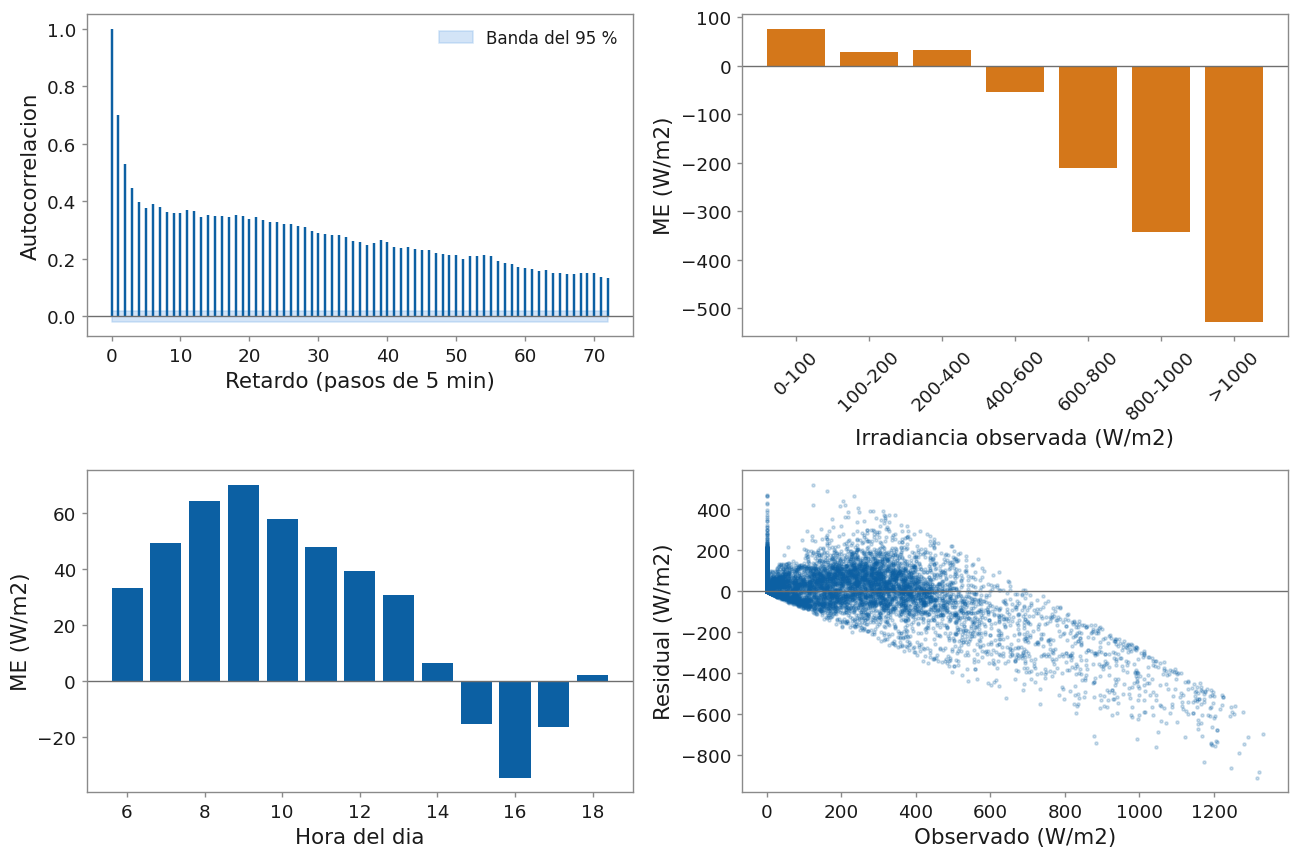

Sin titulo dentro de la imagen: el pie de figura del documento lo aporta.


In [ ]:
# 14. PUNTO 1: diagnostico de residuales (diagnostico de modelo, no validacion de supuestos)
p, t, t_idx = predecir_contiguo(VAR_DIAG, H_DIAG, N_SEG)
t_w  = desnormalizar_rs(t)
# Restriccion fisica aplicada, la misma del cuaderno 06
p_w  = ajustar_prediccion(t_idx[:, None], desnormalizar_rs(p)[:, [0]])[:, 0]
obs0 = t_w[:, 0]
res  = p_w - obs0

ts0   = TIMESTAMPS[t_idx]
hora0 = ts0.hour.values
diurno = (hora0 >= HORA_INI_DIURNO) & (hora0 <= HORA_FIN_DIURNO)

print(f'Modelo diagnosticado: {VAR_DIAG} | horizonte {H_DIAG}')
print(f'Tramo: {ts0[0]}  ->  {ts0[-1]}   n = {len(res):,} '
      f'({diurno.sum():,} diurnos)')
print()
print('SESGO Y ERROR')
print(f'  ME  diurno : {res[diurno].mean():8.2f} W/m2   (+ sobreestima / - subestima)')
print(f'  MAE diurno : {np.mean(np.abs(res[diurno])):8.2f} W/m2')
print(f'  RMSE diurno: {np.sqrt(np.mean(res[diurno]**2)):8.2f} W/m2')

# Los mismos numeros, pero solo donde el valor verdadero salio del sensor.
if OBSERVADO is not None:
    obs_d = diurno & OBSERVADO[t_idx[:, 0] if np.ndim(t_idx) > 1 else t_idx]
    print()
    print('  SOLO SOBRE PUNTOS MEDIDOS (el resto son valores imputados)')
    print(f'  Puntos      : {obs_d.sum():,} de {diurno.sum():,} diurnos '
          f'({100*obs_d.sum()/max(diurno.sum(),1):.1f} %)')
    if obs_d.sum():
        print(f'  ME  diurno : {res[obs_d].mean():8.2f} W/m2')
        print(f'  MAE diurno : {np.mean(np.abs(res[obs_d])):8.2f} W/m2')
        print(f'  RMSE diurno: {np.sqrt(np.mean(res[obs_d]**2)):8.2f} W/m2')
    print('  Esta es la cifra que describe el desempenio frente a la realidad medida;')
    print('  la de arriba mezcla objetivos medidos con objetivos reconstruidos.')

# --- Autocorrelacion de los residuales -----------------------------------
# PARCHE DE LA REVISION: con la restriccion fisica aplicada, el residual
# nocturno es cero exacto. Doce horas de ceros por dia crean una periodicidad
# que no viene del modelo. La ACF se calcula sobre pares diurnos.
NLAGS = 72
r_diurna,   npar_d = acf_enmascarada(res, diurno, NLAGS)
r_completa, npar_c = acf_enmascarada(res, np.ones_like(diurno), NLAGS)

lb_diurna   = ljung_box_enmascarada(r_diurna,   npar_d, [12, 36, 72])
lb_completa = ljung_box_enmascarada(r_completa, npar_c, [12, 36, 72])

print()
print('PRUEBA DE LJUNG-BOX  (H0: ausencia de autocorrelacion en los residuales)')
print('  Estadisticos redondeados a la unidad: tres decimales sobre un valor de')
print('  cinco cifras enteras no aportan informacion.')
print()
print('  Ambito diurno (el que se reporta):')
for _, f in lb_diurna.iterrows():
    print(f"    retardo {int(f['retardo']):>3}   Q = {f['Q']:>10,.0f}   p = {f['p']:.4f}")
print('  Serie completa, incluida la noche (solo como referencia):')
for _, f in lb_completa.iterrows():
    print(f"    retardo {int(f['retardo']):>3}   Q = {f['Q']:>10,.0f}   p = {f['p']:.4f}")
print()
print('  La diferencia entre los dos bloques no mide capacidad predictiva: mide')
print('  cuanta periodicidad artificial introduce la restriccion nocturna.')

lb_diurna.assign(ambito='diurno').to_csv(
    os.path.join(RUTA_RES, 'tabla_07_ljungbox.csv'), index=False)

# --- Figura de diagnostico -----------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

lim = 1.96 / np.sqrt(diurno.sum())
axs[0, 0].vlines(np.arange(NLAGS + 1), 0, r_diurna, color=C_AZUL, lw=1.6)
axs[0, 0].axhline(0, color=C_GRIS, lw=0.9)
axs[0, 0].fill_between([0, NLAGS], -lim, lim, color=C_AZUL_CLARO, alpha=0.35,
                       label='Banda del 95 %')
axs[0, 0].set_xlabel('Retardo (pasos de 5 min)')
axs[0, 0].set_ylabel('Autocorrelacion')
axs[0, 0].legend(frameon=False, fontsize=11)

bins = np.array([0, 100, 200, 400, 600, 800, 1000, 1600])
etiq = ['0-100', '100-200', '200-400', '400-600', '600-800', '800-1000', '>1000']
ib = np.digitize(obs0, bins) - 1
me_bin = [res[diurno & (ib == k)].mean() if (diurno & (ib == k)).sum() > 0 else np.nan
          for k in range(len(etiq))]
axs[0, 1].bar(etiq, me_bin, color=C_AMBAR); axs[0, 1].axhline(0, color=C_GRIS, lw=0.9)
axs[0, 1].set_xlabel('Irradiancia observada (W/m2)'); axs[0, 1].set_ylabel('ME (W/m2)')
axs[0, 1].tick_params(axis='x', rotation=45)

horas_d = np.arange(HORA_INI_DIURNO, HORA_FIN_DIURNO + 1)
me_h = [res[hora0 == h].mean() if (hora0 == h).sum() > 0 else np.nan for h in horas_d]
axs[1, 0].bar(horas_d, me_h, color=C_AZUL); axs[1, 0].axhline(0, color=C_GRIS, lw=0.9)
axs[1, 0].set_xlabel('Hora del dia'); axs[1, 0].set_ylabel('ME (W/m2)')

axs[1, 1].scatter(obs0[diurno], res[diurno], s=4, alpha=0.2)
axs[1, 1].axhline(0, color=C_GRIS, lw=0.9)
axs[1, 1].set_xlabel('Observado (W/m2)'); axs[1, 1].set_ylabel('Residual (W/m2)')

plt.tight_layout()
guardar_figura(fig, f'diagnostico_residuales_{VAR_DIAG}_{H_DIAG}')
plt.show()
print('Sin titulo dentro de la imagen: el pie de figura del documento lo aporta.')

  Figura guardada: prediccion_vs_observacion_repr.png, .svg y .pdf


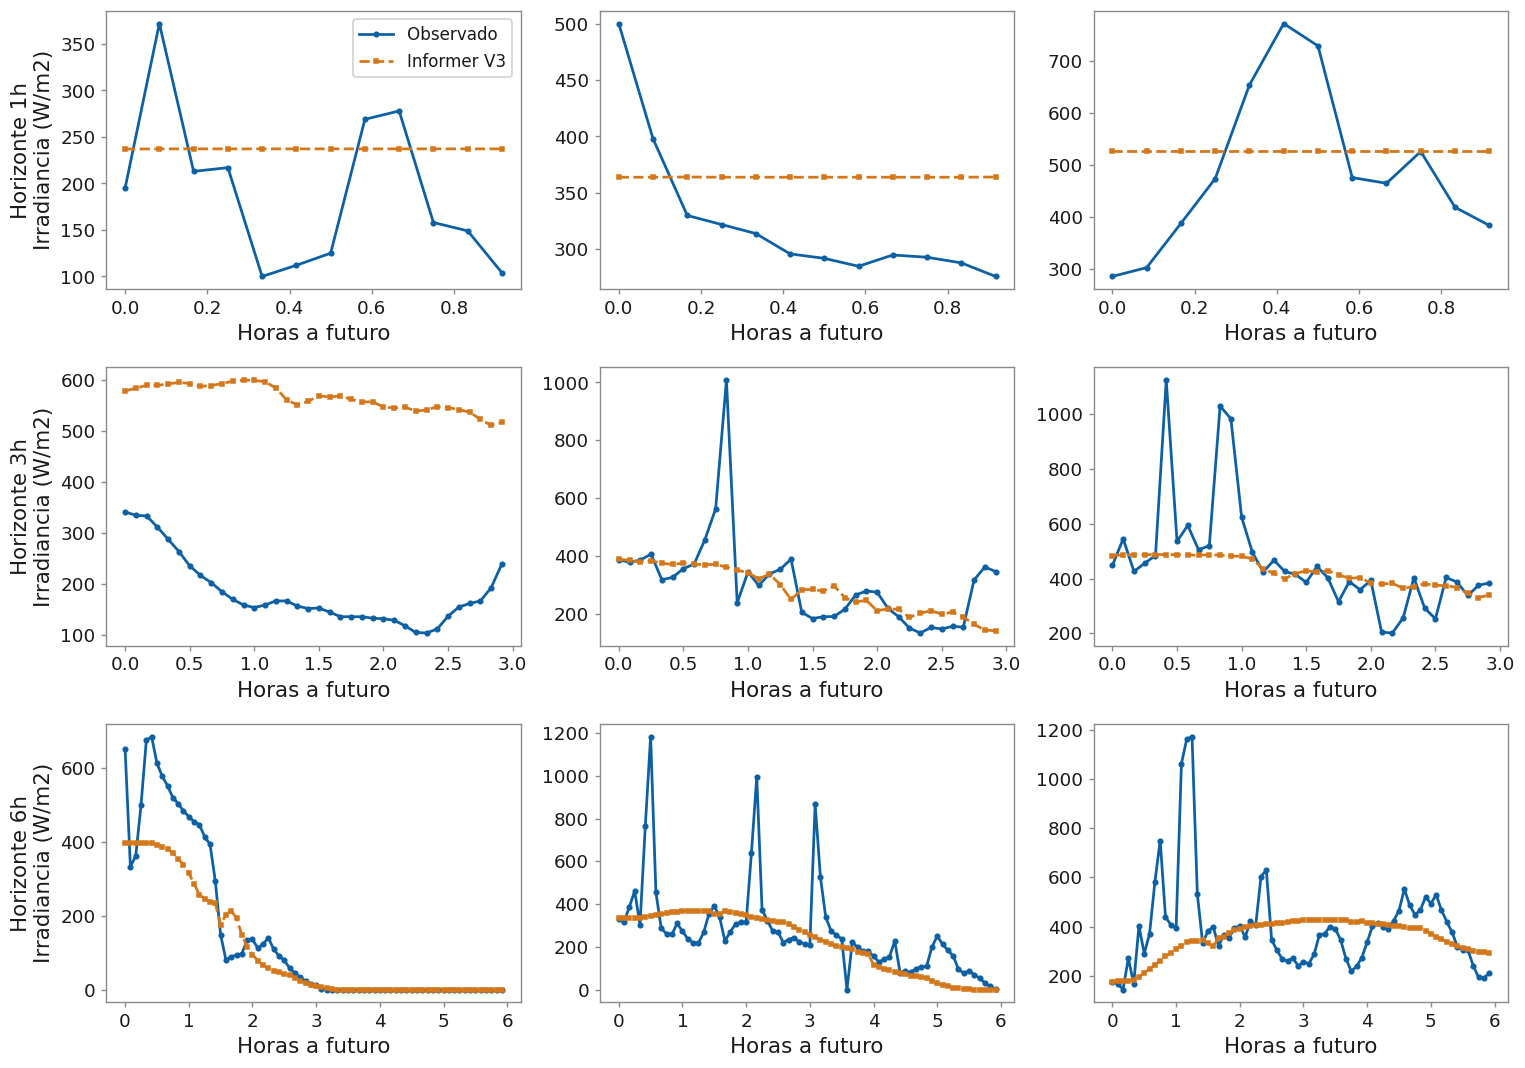

Figura guardada: figuras_SVG/prediccion_vs_observacion_repr.svg


In [ ]:
# 15. PUNTO 2: prediccion frente a observacion con ventanas representativas
# Se eligen ventanas diurnas en los percentiles 25, 50 y 75 de irradiancia media,
# en lugar de la ventana de maxima irradiancia (que exageraba el error).
VAR_EJ = 'V3_completo'   # variante a ilustrar (configurable)

fig, axs = plt.subplots(len(PRED_LENS), 3, figsize=(14, 3.3 * len(PRED_LENS)))
axs = np.atleast_2d(axs)
for r, h in enumerate(PRED_LENS):
    cols = columnas_variante(VAR_EJ)
    data_sub = np.ascontiguousarray(data_norm[:, cols])
    pred_len = PRED_LENS[h]
    # PARCHE DE LA REVISION: el conjunto de prueba empieza en IDX_TEST_INI,
    # no en IDX_VAL_END, que con el embargo es la banda descartada.
    ds = InformerDataset(data_sub, marcas_temp, IDX_TEST_INI, IDX_TEST_FIN,
                         SEQ_LEN, LABEL_LEN, pred_len, idx_objetivo=0)
    loader = DataLoader(Subset(ds, list(range(0, len(ds), 18))), batch_size=128,
                        shuffle=False, num_workers=2, pin_memory=USE_AMP)
    ckpt = os.path.join(RUTA_MODELOS, f'informer_{VAR_EJ}__{h}_{MODO}.pt')
    modelo = build_informer(len(cols), pred_len, HP_BEST)
    modelo.load_state_dict(torch.load(ckpt, map_location=DEVICE)); modelo.eval()
    P, T = [], []
    with torch.no_grad():
        for batch in loader:
            enc, enc_m, dec, dec_m, tgt = _mover(batch)
            with autocast(DEVICE_TYPE, enabled=USE_AMP):
                out = modelo(enc, enc_m, dec, dec_m).squeeze(-1)
            P.append(out.float().cpu().numpy()); T.append(tgt.float().cpu().numpy())
    del modelo; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    P = np.clip(desnormalizar_rs(np.concatenate(P)), 0, None)
    T = desnormalizar_rs(np.concatenate(T))
    media = T.mean(axis=1)
    diurnas = np.where(media > 50)[0]
    ordenadas = diurnas[np.argsort(media[diurnas])]
    sel = [int(ordenadas[min(int(q * len(ordenadas)), len(ordenadas) - 1)]) for q in (0.25, 0.5, 0.75)]
    horas = np.arange(pred_len) * 5 / 60.0
    for cax, idx in zip(axs[r], sel):
        cax.plot(horas, T[idx], 'o-', ms=3, label='Observado')
        cax.plot(horas, P[idx], 's--', ms=3, label='Informer ' + VAR_EJ.split('_')[0])
        cax.set_xlabel('Horas a futuro')
    axs[r, 0].set_ylabel(f'Horizonte {h}\nIrradiancia (W/m2)')
axs[0, 0].legend(fontsize=11)
plt.tight_layout()
guardar_figura(fig, 'prediccion_vs_observacion_repr')
plt.show()
print('Figura guardada: figuras_SVG/prediccion_vs_observacion_repr.svg')

         variable  hf_index  autocorr_lag1  frac_sin_cambio  hf_complemento
               RS    0.0517         0.9362           0.6671          0.0638
               KT    0.0148         0.9956           0.5289          0.0044
ALLSKY_SFC_SW_DWN    0.0066         0.9995           0.4465          0.0005
          WD10M_v    0.0037         0.9995           0.0014          0.0005
               PS    0.0042         0.9996           0.0594          0.0004
          WD10M_u    0.0034         0.9996           0.0013          0.0004
CLRSKY_SFC_SW_DWN    0.0097         0.9996           0.4465          0.0004
              SZA    0.0087         0.9996           0.4465          0.0004
             RH2M    0.0052         0.9996           0.0287          0.0004
              T2M    0.0042         0.9997           0.0043          0.0003
      PRECTOTCORR    0.0010         0.9997           0.1743          0.0003
         cos_hora    0.0077         0.9998           0.0000          0.0002
         sin

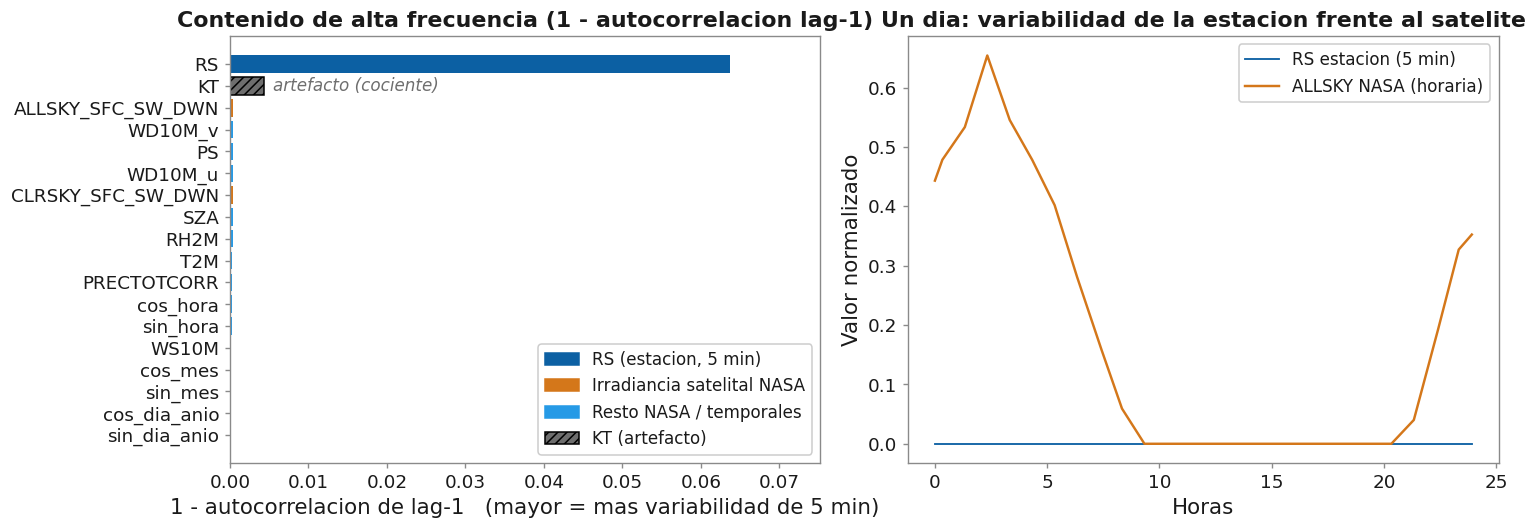

Tabla y figura guardadas: resultados/diagnostico_alta_frecuencia.csv, figuras_SVG/diagnostico_alta_frecuencia.svg


In [ ]:
# 16. PUNTO 3 (revisado): contenido de alta frecuencia medido por autocorrelacion de lag-1
# La autocorrelacion de lag-1 es la metrica mas limpia y defendible: cuanto mas
# cerca de 1, mas suave es la serie entre pasos consecutivos (menos contenido de
# 5 min). Se grafica su complemento (1 - autocorr) para que una barra alta indique
# MAYOR variabilidad de alta frecuencia. El hf_index se conserva en la tabla como
# respaldo, pero NO se usa como metrica principal porque sobrevalora a KT (cociente
# inestable en los bordes del dia).
from matplotlib.patches import Patch

filas_hf = []
for j, v in enumerate(VARS_ENTRADA):
    x = data_norm[:, j].astype(np.float64)
    dif = np.diff(x)
    filas_hf.append(dict(
        variable=v,
        hf_index=float(np.std(dif)),
        autocorr_lag1=float(np.corrcoef(x[:-1], x[1:])[0, 1]),
        frac_sin_cambio=float(np.mean(np.abs(dif) < 1e-6)),
    ))
df_hf = pd.DataFrame(filas_hf)
df_hf['hf_complemento'] = 1.0 - df_hf['autocorr_lag1']
df_hf = df_hf.sort_values('autocorr_lag1').reset_index(drop=True)  # menor autocorr = mas alta frecuencia
df_hf.to_csv(os.path.join(RUTA_RES, 'diagnostico_alta_frecuencia.csv'), index=False)
print(df_hf.round(4).to_string(index=False))

SATELITE_IRR = ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN']
def color_var(v):
    if v == 'RS':         return C_AZUL        # estacion (5 min)
    if v == 'KT':         return C_GRIS        # artefacto del cociente
    if v in SATELITE_IRR: return C_AMBAR       # irradiancia satelital NASA
    return C_CELESTE                            # resto NASA / temporales

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

orden = df_hf.sort_values('hf_complemento', ascending=True)
colores = [color_var(v) for v in orden['variable']]
barras = axs[0].barh(orden['variable'], orden['hf_complemento'], color=colores)
for b, v in zip(barras, orden['variable']):
    if v == 'KT':
        b.set_hatch('////'); b.set_edgecolor('black')
        axs[0].annotate('artefacto (cociente)',
                        xy=(b.get_width(), b.get_y() + b.get_height() / 2),
                        xytext=(6, 0), textcoords='offset points',
                        va='center', fontsize=11, style='italic', color=C_GRIS)
axs[0].set_xlim(0, float(df_hf['hf_complemento'].max()) * 1.18)
axs[0].set_title('Contenido de alta frecuencia (1 - autocorrelacion lag-1)')
axs[0].set_xlabel('1 - autocorrelacion de lag-1   (mayor = mas variabilidad de 5 min)')
leyenda = [Patch(color=C_AZUL, label='RS (estacion, 5 min)'),
           Patch(color=C_AMBAR, label='Irradiancia satelital NASA'),
           Patch(color=C_CELESTE, label='Resto NASA / temporales'),
           Patch(facecolor=C_GRIS, hatch='////', edgecolor='black', label='KT (artefacto)')]
axs[0].legend(handles=leyenda, fontsize=11, loc='lower right')

ini = IDX_TEST_INI + 5000        # PARCHE: dentro del conjunto de prueba real
seg = slice(ini, ini + 288)            # un dia (288 pasos de 5 min)
horas = np.arange(288) * 5 / 60.0
axs[1].plot(horas, data_norm[seg, VARS_ENTRADA.index('RS')], lw=1.2, label='RS estacion (5 min)')
axs[1].plot(horas, data_norm[seg, VARS_ENTRADA.index('ALLSKY_SFC_SW_DWN')], lw=1.6, label='ALLSKY NASA (horaria)')
axs[1].set_title('Un dia: variabilidad de la estacion frente al satelite')
axs[1].set_xlabel('Horas'); axs[1].set_ylabel('Valor normalizado'); axs[1].legend(fontsize=11)

plt.tight_layout()
guardar_figura(fig, 'diagnostico_alta_frecuencia')
plt.show()
print('Tabla y figura guardadas: resultados/diagnostico_alta_frecuencia.csv, figuras_SVG/diagnostico_alta_frecuencia.svg')

## Resumen de salidas para Juan (seccion de Resultados)

- `resultados/metricas_variantes.csv` — tabla ampliada con error medio (ME) global y diurno, ademas de MAE, RMSE, R2, sMAPE y *skill* frente a persistencia.
- `figuras/diagnostico_residuales_*.png` — ACF y Ljung-Box (autocorrelacion residual), sesgo por nivel de irradiancia y por hora, y residual frente a observado.
- `figuras/prediccion_vs_observacion_repr.png` — prediccion frente a observacion en ventanas representativas.
- `resultados/diagnostico_alta_frecuencia.csv` y `figuras/diagnostico_alta_frecuencia.png` — evidencia de que la irradiancia satelital horaria de NASA carece del contenido de alta frecuencia de la RS de 5 min.

**Lectura sugerida:** el ME negativo y su concentracion en niveles altos de irradiancia documentan que el modelo subestima los picos; la autocorrelacion residual a retardos cortos confirma que queda dinamica de corto plazo sin capturar; y el diagnostico de alta frecuencia sustenta, de forma cuantitativa, por que agregar la irradiancia satelital horaria no mejora la prediccion a 5 minutos.